<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 2 — Análisis de señales biomédicas con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->

<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Representación temporal, FFT y STFT de señales fisiológicas </font><br>
</div>

---


## Objetivo

En este ejercicio se trabajará con tres registros de la base **NSRDB (Normal Sinus Rhythm Database)** de PhysioNet.

El estudiante deberá:

1. Importar registros fisiológicos desde PhysioNet mediante `wfdb`.
2. Identificar la frecuencia de muestreo y las características básicas de cada señal.
3. Representar las señales en el dominio del tiempo.
4. Analizar su contenido frecuencial mediante la **Transformada Rápida de Fourier (FFT)**.
5. Comparar el espectro antes y después de eliminar la componente DC.
6. Analizar cómo cambia el contenido frecuencial a lo largo del tiempo mediante **STFT** y espectrogramas.
7. Comparar los tres registros y formular conclusiones.

> **Idea central:** una señal puede estudiarse desde el dominio temporal, el dominio frecuencial y el dominio tiempo-frecuencia.


## 1. Introducción

Una señal biomédica contiene información que puede observarse desde diferentes perspectivas.

### Dominio temporal

Permite estudiar cómo cambia la amplitud de la señal con el tiempo:
<!-- Este es un comentario y no aparecerá visualmente en Colab $$
t[n]=\frac{n}{f_s}
$$   \[
t[n]=\frac{n}{f_s}
\]   -->

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio frecuencial

La FFT permite analizar qué componentes de frecuencia están presentes en una señal:

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio tiempo-frecuencia

La STFT permite observar cómo evoluciona el contenido frecuencial a lo largo del tiempo.

En este ejercicio se analizarán tres registros:

- `16265`
- `16272`
- `16420`

pertenecientes a la base `nsrdb`.


## 2. Parámetros del ejercicio

Cada registro se cargará utilizando las primeras **10 segundos** de información.

| Parámetro | Valor |
|---|---|
| Base de datos | `nsrdb` |
| Registro 1 | `16265` |
| Registro 2 | `16272` |
| Registro 3 | `16420` |
| Muestras | `3600` por registro |
| Canal analizado | `0` |

### Pregunta inicial

Antes de ejecutar el notebook:

**¿Qué diferencia espera encontrar entre analizar una señal en el dominio del tiempo y analizarla en el dominio de la frecuencia?**


In [ ]:
# ============================================
# PARÁMETROS
# ============================================

DATABASE = "nsrdb"

RECORDS = ["16265", "16272", "16420"]

SAMPFROM = 1
SAMPLING_POINTS = 3600

CHANNEL = 1

print("Parámetros del ejercicio")
print("=" * 45)
print(f"Base de datos       : {DATABASE}")
print(f"Registros           : {RECORDS}")
print(f"Muestras por señal  : {SAMPLING_POINTS}")
print(f"Canal seleccionado  : {CHANNEL}")


Parámetros del ejercicio
Base de datos       : nsrdb
Registros           : ['16265', '16272', '16420']
Muestras por señal  : 3600
Canal seleccionado  : 1


## 3. Instalación e importación de librerías

Se utilizarán:

- **WFDB:** acceso a registros fisiológicos de PhysioNet.
- **NumPy:** procesamiento numérico y FFT.
- **SciPy:** cálculo de la STFT.
- **Matplotlib:** visualización.


In [ ]:
# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!pip install -q wfdb scipy numpy matplotlib


In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 4. Cargar los tres registros desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

El parámetro `pn_dir` permite indicar la base de datos disponible en PhysioNet.

También se intentará cargar la anotación `atr` de cada registro para dejar disponible la información de anotaciones cuando exista.


In [ ]:
# ============================================
# CARGAR LOS TRES REGISTROS
# ============================================

records_data = {}

for record_name in RECORDS:
    record = wfdb.rdrecord(
        record_name,
        pn_dir=DATABASE,
        sampfrom=SAMPFROM,
        sampto=SAMPFROM + SAMPLING_POINTS
    )

    records_data[record_name] = record

    print(f"Registro {record_name} cargado correctamente.")


Registro 16265 cargado correctamente.
Registro 16272 cargado correctamente.
Registro 16420 cargado correctamente.


In [ ]:
# ============================================
# CARGAR ANOTACIONES
# ============================================

annotations = {}

for record_name in RECORDS:
    try:
        annotation = wfdb.rdann(
            record_name,
            "atr",
            pn_dir=DATABASE,
            sampfrom=SAMPFROM,
            sampto=SAMPFROM + SAMPLING_POINTS
        )
        annotations[record_name] = annotation
        print(f"Anotaciones del registro {record_name}: {len(annotation.sample)}")
    except Exception as e:
        annotations[record_name] = None
        print(f"No fue posible cargar anotaciones para {record_name}: {e}")


Anotaciones del registro 16265: 46
Anotaciones del registro 16272: 31
Anotaciones del registro 16420: 44


## 5. Explorar la información de los registros

Antes de realizar cualquier análisis es importante conocer:

- frecuencia de muestreo;
- número de muestras;
- número de canales;
- nombre de los canales;
- unidades de medida.



In [ ]:
# ============================================
# INFORMACIÓN DE LOS REGISTROS
# ============================================

for record_name, record in records_data.items():
    duration = record.sig_len / record.fs

    print("=" * 60)
    print(f"REGISTRO: {record_name}")
    print("=" * 60)
    print(f"Frecuencia de muestreo : {record.fs} Hz")
    print(f"Número de muestras     : {record.sig_len}")
    print(f"Número de canales      : {record.n_sig}")
    print(f"Canales                : {record.sig_name}")
    print(f"Unidades               : {record.units}")
    print(f"Duración analizada     : {duration:.2f} s")


REGISTRO: 16265
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16272
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16420
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s


### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo de cada registro?
2. ¿Los tres registros tienen la misma frecuencia de muestreo?
3. ¿Cuántos canales posee cada registro?
4. ¿Qué señal corresponde al canal `0`?
5. ¿Cuántas muestras contiene cada registro?
6. ¿Por qué `3600` muestras corresponden aproximadamente a 10 segundos cuando `fs = 360 Hz`?


# 6. Extracción de las señales y construcción del eje temporal

Las muestras se encuentran en:

```python
record.p_signal
```

La estructura tiene la forma:

```text
(muestras, canales)
```

Por ello, para seleccionar el canal indicado:

```python
x = record.p_signal[:, CHANNEL]
```

El eje temporal se construye mediante:

\[
t[n]=rac{n}{f_s}
\]


In [ ]:
# ============================================
# EXTRAER SEÑALES Y EJES TEMPORALES
# ============================================

signals = {}
times = {}
sampling_rates = {}

for record_name, record in records_data.items():
    x = record.p_signal[:, CHANNEL]
    fs = record.fs

    signals[record_name] = x
    sampling_rates[record_name] = fs
    times[record_name] = np.arange(len(x)) / fs

    print(
        f"{record_name}: "
        f"{len(x)} muestras, "
        f"fs = {fs} Hz, "
        f"canal = {record.sig_name[CHANNEL]}"
    )


16265: 3600 muestras, fs = 128 Hz, canal = ECG2
16272: 3600 muestras, fs = 128 Hz, canal = ECG2
16420: 3600 muestras, fs = 128 Hz, canal = ECG2


# 7. Gráficas — Amplitud vs. tiempo

Primero observaremos las tres señales en el dominio temporal.

### ¿Qué debemos observar?

- amplitud;
- duración;
- forma de onda;
- periodicidad;
- cambios o eventos particulares;
- diferencias entre registros.


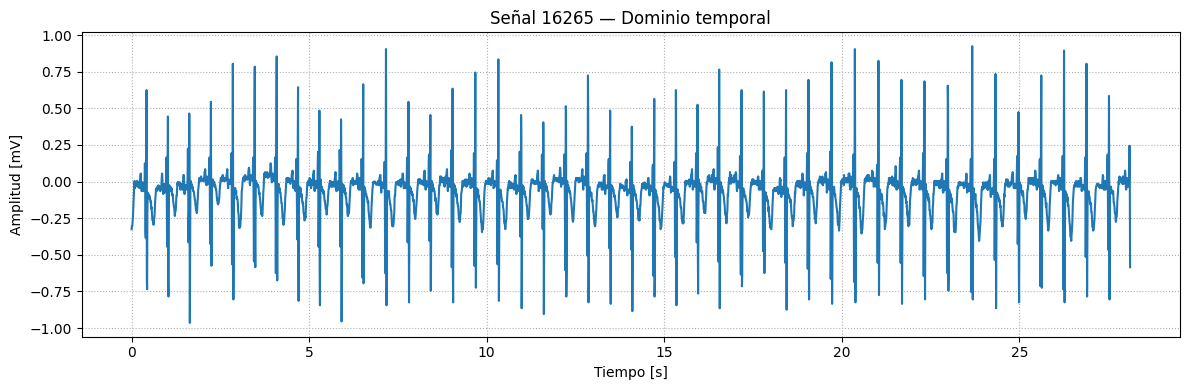

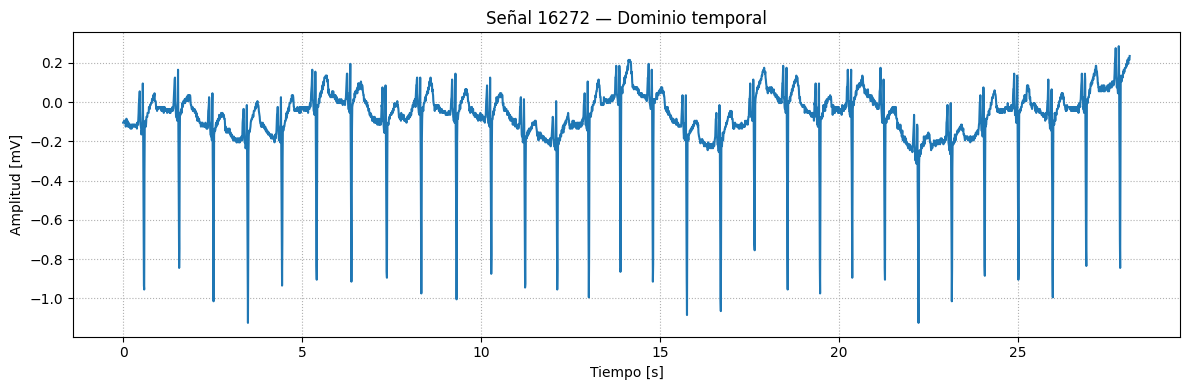

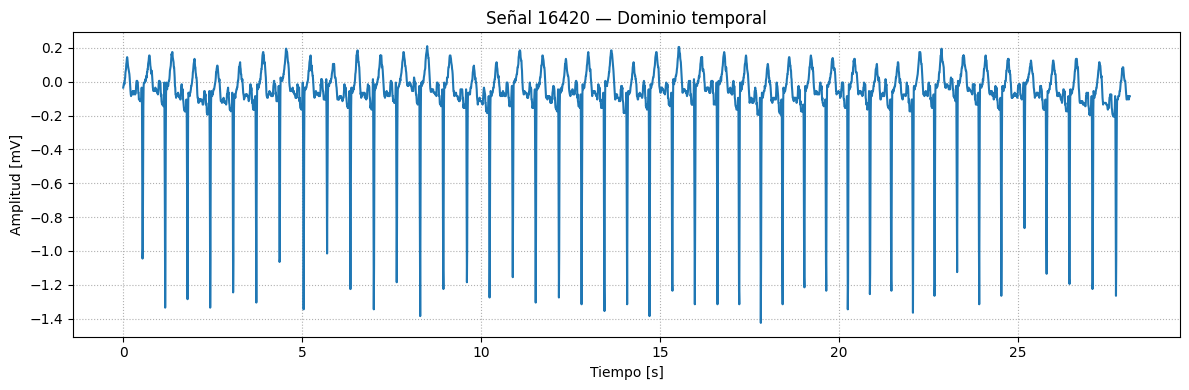

In [ ]:
# ============================================
# DOMINIO TEMPORAL — TRES REGISTROS
# ============================================

for record_name in RECORDS:
    record = records_data[record_name]
    x = signals[record_name]
    t = times[record_name]

    plt.figure(figsize=(12, 4))
    plt.plot(t, x)

    plt.title(f"Señal {record_name} — Dominio temporal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


### Preguntas de análisis 2

1. ¿Las tres señales presentan una morfología similar?
2. ¿Cuál presenta mayor variación de amplitud?
3. ¿Se observan patrones periódicos?
4. ¿Se identifican eventos o cambios particulares?
5. ¿Qué información puede obtenerse fácilmente desde la gráfica temporal?


# 8. Transformada Rápida de Fourier (FFT)

La FFT permite transformar una señal del dominio temporal al dominio frecuencial.

Antes de calcularla consideraremos dos casos:

### Caso A — señal original

\[
x[n]
\]

### Caso B — señal sin componente DC

\[
x_{AC}[n]=x[n]-\overline{x}
\]

La componente DC está asociada con el valor medio de la señal y aparece alrededor de **0 Hz** en el espectro.

Para comparar correctamente los registros utilizaremos el espectro de un solo lado, correspondiente a las frecuencias positivas.


In [ ]:
# ============================================
# FUNCIÓN PARA CALCULAR FFT
# ============================================

def calculate_fft(x, fs):
    n = len(x)

    x_dc_removed = x - np.mean(x)

    spectrum_original = np.fft.rfft(x)
    spectrum_ac = np.fft.rfft(x_dc_removed)

    frequencies = np.fft.rfftfreq(n, d=1/fs)

    magnitude_original = np.abs(spectrum_original)
    magnitude_ac = np.abs(spectrum_ac)

    return (
        frequencies,
        magnitude_original,
        magnitude_ac,
        x_dc_removed
    )


In [ ]:
# ============================================
# CALCULAR FFT PARA LOS TRES REGISTROS
# ============================================

fft_data = {}

for record_name in RECORDS:
    fs = sampling_rates[record_name]
    x = signals[record_name]

    frequencies, magnitude_original, magnitude_ac, x_dc_removed = calculate_fft(
        x, fs
    )

    fft_data[record_name] = {
        "frequencies": frequencies,
        "magnitude_original": magnitude_original,
        "magnitude_ac": magnitude_ac,
        "signal_ac": x_dc_removed
    }

    print(
        f"{record_name}: "
        f"frecuencia máxima analizada = {frequencies[-1]:.2f} Hz"
    )


16265: frecuencia máxima analizada = 64.00 Hz
16272: frecuencia máxima analizada = 64.00 Hz
16420: frecuencia máxima analizada = 64.00 Hz


## 9. FFT de la señal original y de la señal sin DC

Para cada registro se mostrarán dos espectros:

1. **FFT con componente DC**
2. **FFT después de eliminar la media**

El objetivo es observar cómo cambia el espectro al retirar la componente de frecuencia cero.


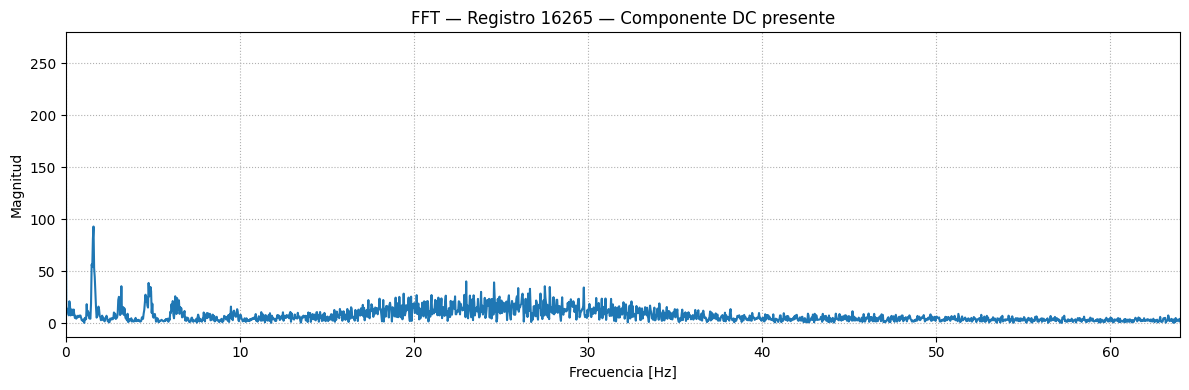

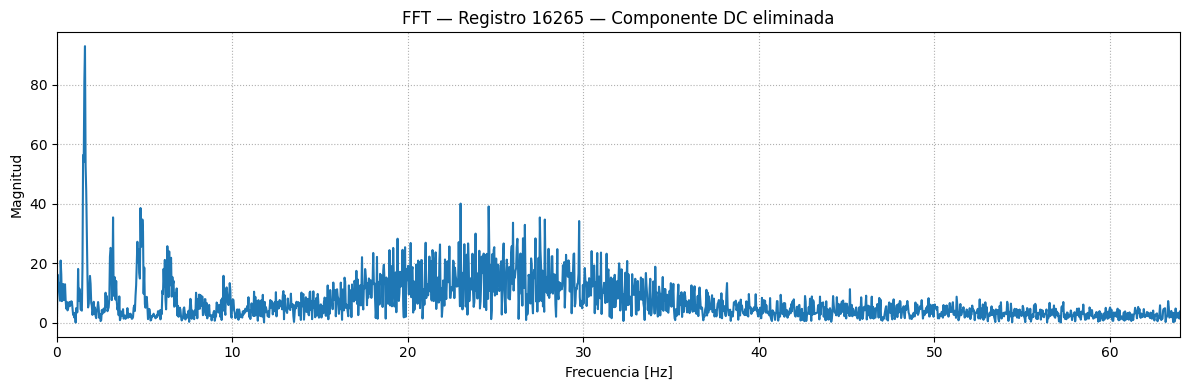

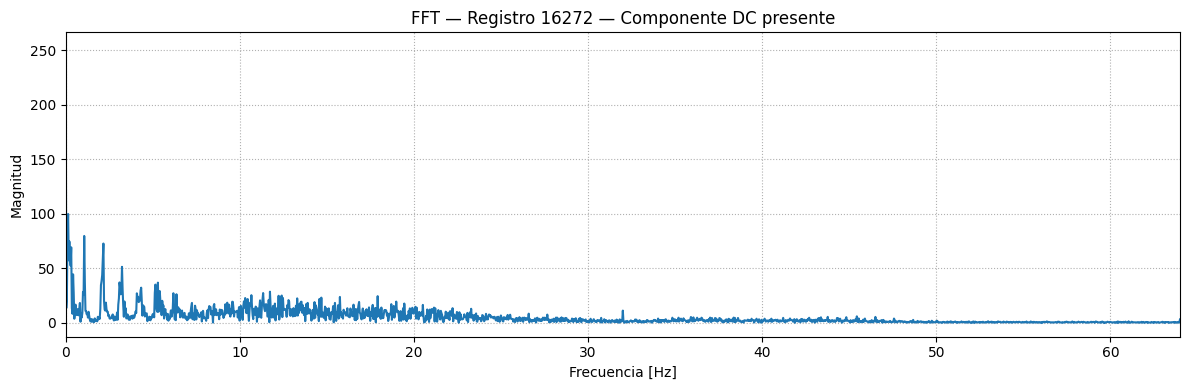

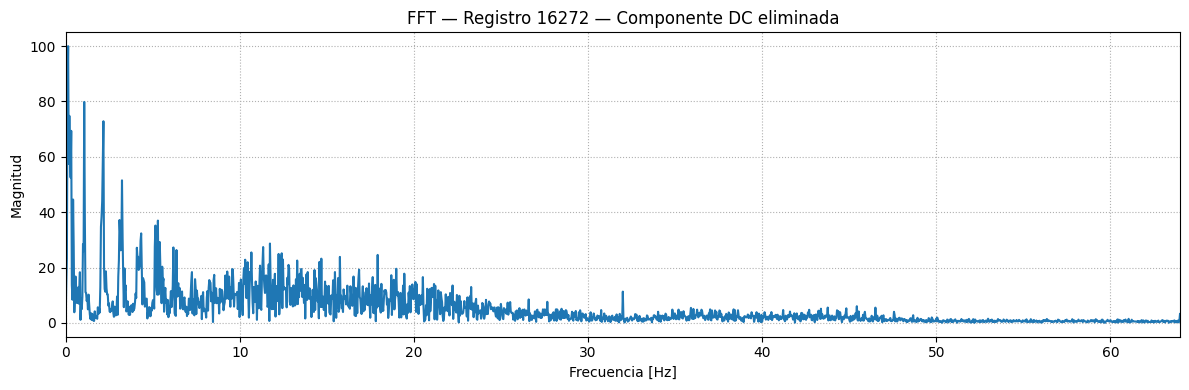

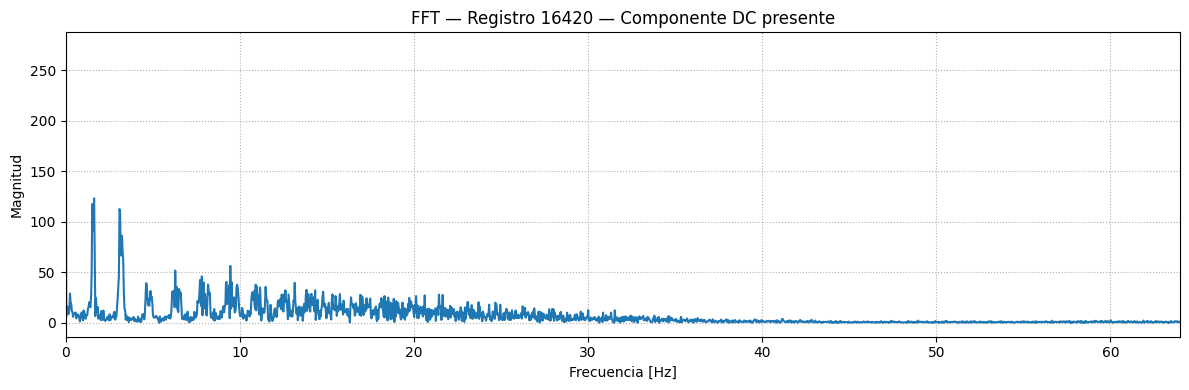

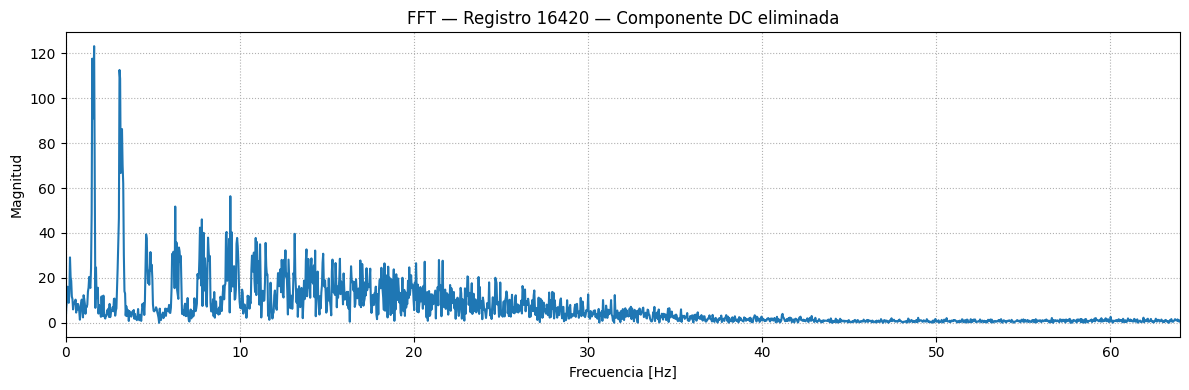

In [ ]:
# ============================================
# FFT — COMPARACIÓN CON Y SIN DC
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]
    f = data["frequencies"]

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_original"])
    plt.title(f"FFT — Registro {record_name} — Componente DC presente")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_ac"])
    plt.title(f"FFT — Registro {record_name} — Componente DC eliminada")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


### Preguntas de análisis 3

1. ¿Qué ocurre con el componente cercano a 0 Hz después de eliminar la media?
2. ¿Qué diferencias observa entre los espectros de los tres registros?
3. ¿En qué intervalo de frecuencias se concentra la mayor parte de la energía?
4. ¿Por qué la FFT no conserva directamente la información temporal?
5. ¿Qué ventaja ofrece observar una señal en el dominio frecuencial?


# 10. Identificación de la frecuencia dominante

Como ejercicio adicional, podemos localizar la frecuencia con mayor magnitud después de retirar la componente DC.

> **Importante:** la frecuencia dominante encontrada mediante FFT no debe interpretarse automáticamente como una frecuencia fisiológica específica. Es necesario considerar el tipo de señal, el procesamiento aplicado y el contexto del registro.


In [ ]:
# ============================================
# FRECUENCIA DOMINANTE
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]

    # Ignorar 0 Hz para evitar seleccionar nuevamente la componente DC
    idx = np.argmax(data["magnitude_ac"][1:]) + 1

    dominant_frequency = data["frequencies"][idx]
    dominant_magnitude = data["magnitude_ac"][idx]

    print(
        f"Registro {record_name}: "
        f"frecuencia dominante = {dominant_frequency:.3f} Hz, "
        f"magnitud = {dominant_magnitude:.3f}"
    )


Registro 16265: frecuencia dominante = 1.600 Hz, magnitud = 92.895
Registro 16272: frecuencia dominante = 0.142 Hz, magnitud = 99.954
Registro 16420: frecuencia dominante = 1.636 Hz, magnitud = 123.101


# 11. STFT — Transformada de Fourier de Tiempo Corto

La FFT proporciona información sobre el contenido frecuencial global de una señal.

Sin embargo, si queremos saber **cuándo** aparecen determinadas componentes de frecuencia necesitamos una representación tiempo-frecuencia.

La STFT divide la señal en ventanas y calcula una FFT para cada ventana.

Conceptualmente:

```text
Señal completa
      ↓
┌────────┬────────┬────────┬────────┐
│ Ventana│ Ventana│ Ventana│ Ventana│
└────────┴────────┴────────┴────────┘
      ↓
     FFT para cada ventana
      ↓
Espectrograma
```

El tamaño de ventana determina un compromiso entre resolución temporal y resolución frecuencial:

- ventana pequeña → mejor resolución temporal;
- ventana grande → mejor resolución frecuencial.


In [ ]:
# ============================================
# STFT — FUNCIÓN DE CÁLCULO
# ============================================

def calculate_stft(x, fs, nperseg=256):
    f, t, zxx = signal.stft(
        x,
        fs=fs,
        nperseg=nperseg
    )

    return f, t, zxx


## 12. STFT de los registros

Para los registros 1 y 3 utilizaremos una ventana de 256 muestras.

Para el registro 2 utilizaremos una ventana más pequeña de 32 muestras, siguiendo el esquema del ejercicio de referencia, con el propósito de conservar mejor eventos verticales/localizados en el tiempo.

### Parámetro importante

```python
nperseg
```

representa el número de muestras de cada ventana.


In [ ]:
# ============================================
# CALCULAR STFT
# ============================================

WINDOWS = {
    "16265": 256,
    "16272": 256,
    "16420": 256
}

stft_data = {}

for record_name in RECORDS:
    x = fft_data[record_name]["signal_ac"]
    fs = sampling_rates[record_name]
    nperseg = WINDOWS[record_name]

    f, t, zxx = calculate_stft(
        x,
        fs,
        nperseg=nperseg
    )

    stft_data[record_name] = {
        "f": f,
        "t": t,
        "zxx": zxx
    }

    print(
        f"{record_name}: "
        f"nperseg = {nperseg}, "
        f"ventanas calculadas = {len(t)}"
    )


16265: nperseg = 256, ventanas calculadas = 30
16272: nperseg = 256, ventanas calculadas = 30
16420: nperseg = 256, ventanas calculadas = 30


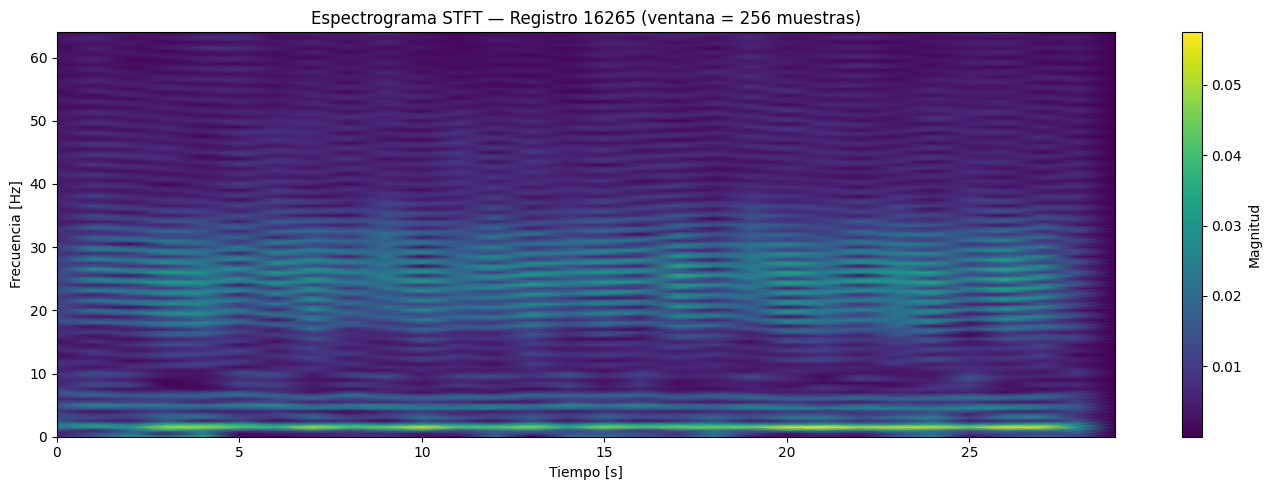

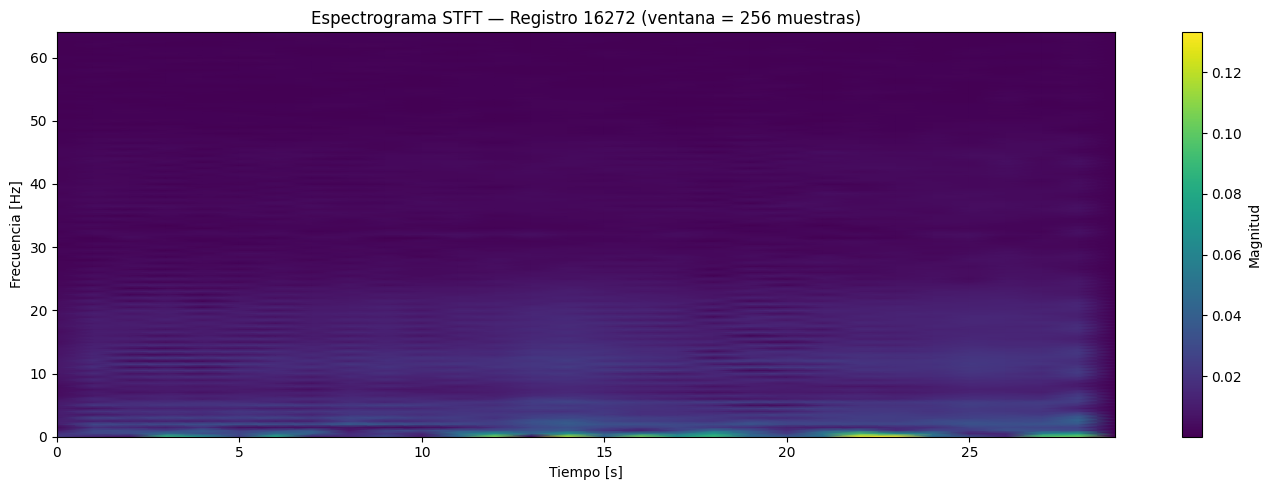

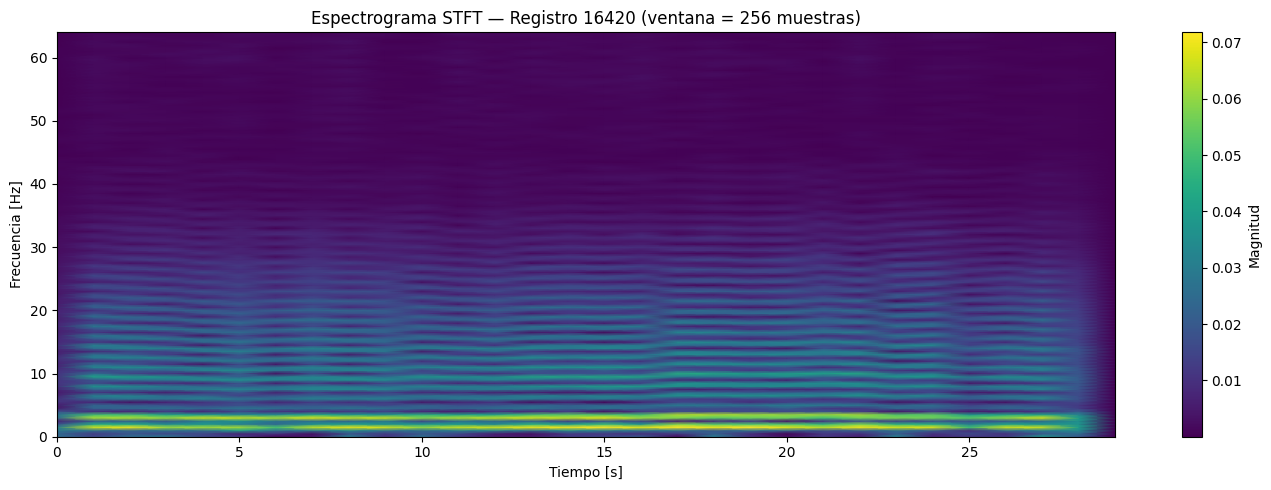

In [ ]:
# ============================================
# ESPECTROGRAMAS STFT
# ============================================

for record_name in RECORDS:
    data = stft_data[record_name]

    f = data["f"]
    t = data["t"]
    zxx = data["zxx"]

    plt.figure(figsize=(14, 5))

    plt.pcolormesh(
        t,
        f,
        np.abs(zxx),
        shading="gouraud"
    )

    plt.title(
        f"Espectrograma STFT — Registro {record_name} "
        f"(ventana = {WINDOWS[record_name]} muestras)"
    )
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.colorbar(label="Magnitud")

    plt.tight_layout()
    plt.show()


### Preguntas de análisis 4

1. ¿Qué información adicional proporciona la STFT respecto a la FFT?
2. ¿En qué momentos se observan cambios de energía?
3. ¿Qué diferencias observa entre los tres espectrogramas?
4. ¿Por qué el registro `16272` utiliza una ventana de 32 muestras?
5. ¿Qué podría ocurrir si se utiliza una ventana demasiado grande?
6. ¿Qué podría ocurrir si se utiliza una ventana demasiado pequeña?


# 13. Comparación de los tres registros

Complete la siguiente tabla a partir de los resultados obtenidos.

| Característica | Registro 16265 | Registro 16272 | Registro 16420 |
|---|---|---|---|
| Frecuencia de muestreo | 128 Hz | 128 Hz | 128 Hz |
| Número de muestras | 3600 | 3600 | 3600 |
| Número de canales | 2 | 2 | 2 |
| Amplitud observada | 2.95 mV | 1.75 mV | 2.75 mV |
| Componente DC | | | |
| Frecuencias dominantes | 3.200 Hz | 0.142 Hz | 9.458 Hz |
| Comportamiento STFT | | | |
| Observaciones | | | |

### Discusión

Explique:

- qué registro presenta mayor variabilidad;
- qué diferencias aparecen en el dominio temporal;
- qué diferencias aparecen en el dominio frecuencial;
- qué información adicional aporta la STFT;
- cómo influye el tamaño de ventana.


# 14. Ejercicios propuestos

## Ejercicio 2.1 — Cambiar el segmento temporal

Modifique:

```python
SAMPFROM = 1
```

para analizar otra región del registro.

Por ejemplo, pruebe con un segmento posterior del registro.

### Analice

1. ¿La morfología cambia? Sí, la morfología de los 3 ECG cambia.
2. ¿El espectro cambia? El espectro de frecuencias permanece sin cambios.
3. ¿La STFT muestra nuevos eventos? Tampoco hay nuevos eventos en la STFT.
4. ¿Qué diferencias encuentra respecto al segmento original? Que a pesar del cambio en la morfología de la señal, no se presentan cambios en el espectro de frecuencias ni en la STFT porque la morfología depende del segmento de la señal y el espectro de frecuencias y STFT depende de las componentes frecuenciales de la señal, mientras no hayan cambios sobre estos, tanto el espectro como la STFT se mantendrán igual.

---

## Ejercicio 2.2 — Cambiar el tamaño de ventana

Para el registro `16272`, compare:

```python
nperseg = 32
```

con:

```python
nperseg = 128
```

y:

```python
nperseg = 256
```

### Responda

1. ¿Cuál permite observar mejor los eventos temporales? El nperseg = 32 permite observar mejor los eventos temporales del histograma.
2. ¿Cuál proporciona mayor detalle en frecuencia? Un nperseg = 256 proporciona mayor detalle en frecuencia puesto que hay mayor número de ventanas en el histograma y se puede observar más detalladamente.
3. ¿Cuál considera más apropiada para este registro? Justifique. Para el registro 16272 considero que es mejor un nperseg = 32, porque las frecuencias relevantes se encuentran en niveles bajos. Por eso es que se aprecian mejor las frecuencias al usar el valor de 32.

---

## Ejercicio 2.3 — Comparación FFT vs. STFT

Explique con sus propias palabras:

> ¿Por qué una FFT global puede ocultar cuándo ocurre un determinado evento, mientras que una STFT puede localizarlo temporalmente?


Lo que hace una FFT global al aplicarla a una señal te da como resultado las frecuencias que están presentes así como su magnitud y fase, sin embargo todos los coeficientes de frecuencia se calcularon usando la señal completa es decir que la integral que define la FFT integra en todo el dominio del tiempo. Esto matemáticamente significa que la integral da como resultado un número complejo por cada frecuencia, el problema es que si por ejemplo un impulso ocurre en el segundo 5 la integral distribuye su energía entre todos los coeficientes de frecuencia pero no se puede saber cuándo pasó. Por otro lado la STFT resuelve este problema porque no se aplica a toda la señal si no que se aplica la FFT en ventanas cortas y superpuestas a lo largo del tiempo. Como cada FFT se calcula sobre un fragmento pequeño el resultado final es un espectrograma: una función de frecuencia y tiempo. En este caso si un evento ocurre en el segundo  5, solo las ventanas centradas cerca del segundo 5 mostrarán ese contenido espectral.

# 15. Preguntas conceptuales

Responda con sus propias palabras.

### 1.¿Qué es PhysioNet?
PhysioNet es un repositorio con amplias bases de datos de señales biológicas que se pueden utilizar para análisis y proyectos, es fácil de acceder y la data se puede descargar con tan solo registrarse.

### 2.¿Qué información proporciona `record.p_signal`?
Contiene los valores de amplitud de la señal fisiológica con sus unidades físicas (mv u otro) no en los valores del ADC. Cada columna está relacionada a un canal distinto del registro y cada fila es una muestra tomada en el tiempo. Por eso para extraer una sola señal se usa record.p_signal[:, CHANNEL].

### 3.¿Qué representa la frecuencia de muestreo `fs`?
La  frecuencia de muestreo es la velocidad con la que se toma una muestra por segundo y se expresa en HZ.
### 4.¿Qué representa la componente DC de una señal?
La componente DC de una señal representa el valor medio de la señal. Indica el desplazamiento vertical de la señal respecto al valor cero. En análisis de fourier la componente DC corresponde a la frecuencia de 0 Hz
### 5.¿Por qué se resta la media antes de analizar el espectro AC?
Se resta porque es común que la componente DC tenga una magnitud mucho mayor que el resto de las componentes frecuenciales por lo que al graficar el espectro esa magnitud se verá muy predominante con respecto a las otras, lo que ocasiona que se desplace la frecuencia de interés. Al restar la media se elimina el offset y se pueden apreciar mejor las componentes frecuenciales distintas a ceros
### 6.¿Qué información proporciona la FFT?
La Transformada Rápida de Fourier (FFT, por sus siglas en inglés) proporciona información detallada sobre el contenido en frecuencia, la amplitud y la fase de una señal compleja al transformarla del dominio del tiempo al dominio de la frecuencia.Cada valor de la frecuencia se calcula usando toda la duración de la señal.  
### 7.¿Qué información adicional proporciona la STFT?
Como se mencionó anteriormente  la STFT divide la señal en señales cortas y calcula una FFT en cada una obteniendo así un espectrograma que muestra cómo cambia el contenido frecuencial a lo largo del tiempo. Así se puede saber no solo qué frecuencias existen, sino también cuándo aparecen o desaparecen lo cual es muy útil en la práctica.
### 8.¿Qué relación existe entre `fs`, número de muestras y duración?
La frecuencia de muestreo determina cuántos datos se capturan por cada segundo de tiempo; por lo tanto, si se incrementa el tiempo de toma de datos o se toman más muestras por segundo, la cantidad total de datos recopilados aumentará de forma proporcional (n), permitiendo también calcular la duración exacta de la señal al dividir el número de muestras entre la frecuencia T = N / f_s.
### 9.¿Qué efecto tiene aumentar el tamaño de ventana de la STFT?
Si se aumenta el tamaño de la ventana se mejora la resolución de la frecuencia porque se incluye una mayor cantidad de señal, lo que permite identificar con mejor precisión qué frecuencias exactas componen el sonido. Sin embargo, se pierde resolución temporal, se pierde la capacidad de saber el momento exacto en el que ocurren los cambios rápidos o eventos transitorios
### 10.¿Por qué no es suficiente utilizar únicamente una representación temporal para analizar completamente una señal biomédica?
Una representación temporal no es suficiente para analizar una señal biomédica porque se oculta la información de frecuencia que define los ritmos biológicos y las patologías, mostrando únicamente cambios de amplitud que a menudo están enmascarados por el ruido. En señales como un EEG o un ECG, las alteraciones críticas o los componentes específicos ocurren a frecuencias exactas que no se pueden cuantificar a simple vista en el tiempo. También un factor importante a considerar es el ruido muscular o las interferencias eléctricas se mezclan directamente con la señal en el dominio temporal, se vuelve indispensable recurrir al análisis de tiempo-frecuencia para separar los componentes, filtrar los artefactos y extraer variables diagnósticas vitales que sino serian invisibles

# 16. Reto final

Seleccione uno de los tres registros y realice un análisis completo:

```text
PhysioNet
   ↓
Seleccionar registro
   ↓
Cargar señal
   ↓
Identificar fs y canales
   ↓
Representar en el tiempo
   ↓
Calcular FFT
   ↓
Eliminar componente DC
   ↓
Comparar espectros
   ↓
Calcular STFT
   ↓
Analizar espectrograma
   ↓
Interpretar resultados
```

### Entregable

El informe debe incluir:

1. Registro seleccionado.
2. Frecuencia de muestreo.
3. Canal analizado.
4. Gráfica temporal.
5. FFT con DC.
6. FFT sin DC.
7. Espectrograma STFT.
8. Comparación de resultados.
9. Respuestas a las preguntas de análisis.
10. Conclusiones.


### Informe:
1. Registro elegido: 16420
2. Frecuencia de muestreo: 128 Hz
3. Canal analizado: Canal 1
4. Gráfica temporal:
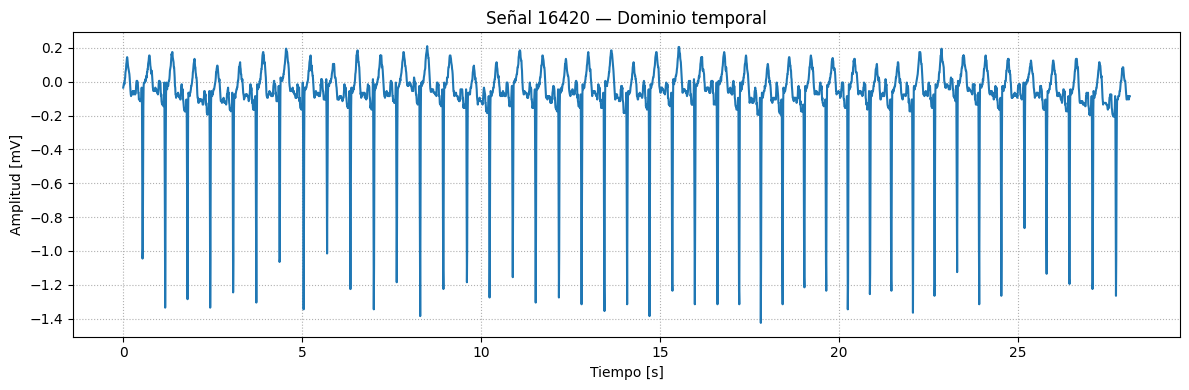
5. FFT con DC:
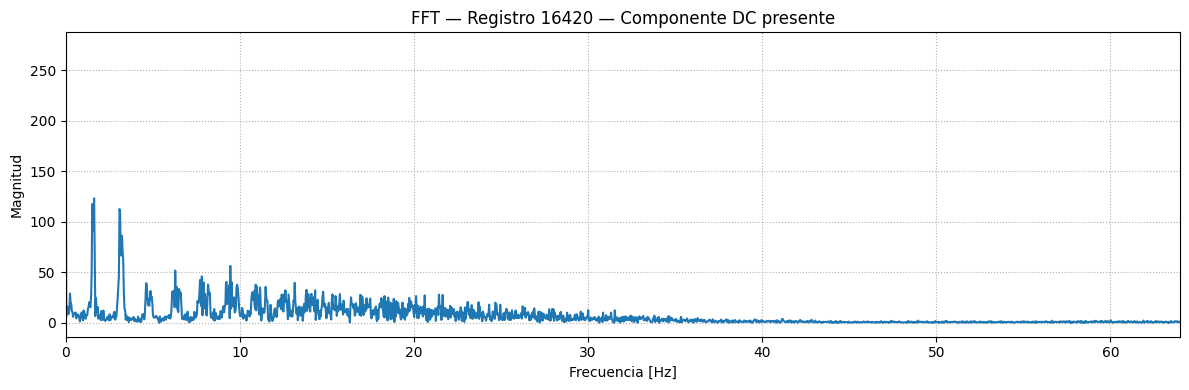
6. FFT sin DC:
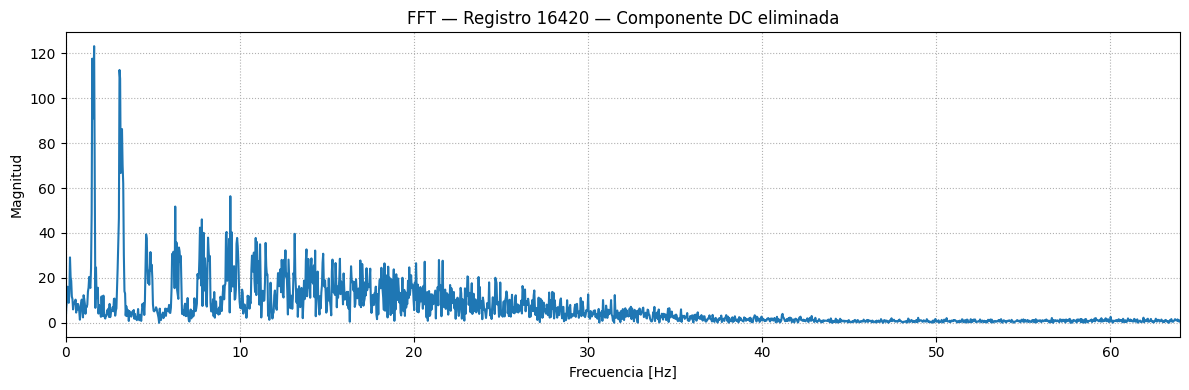
7. Espectrograma STFT:
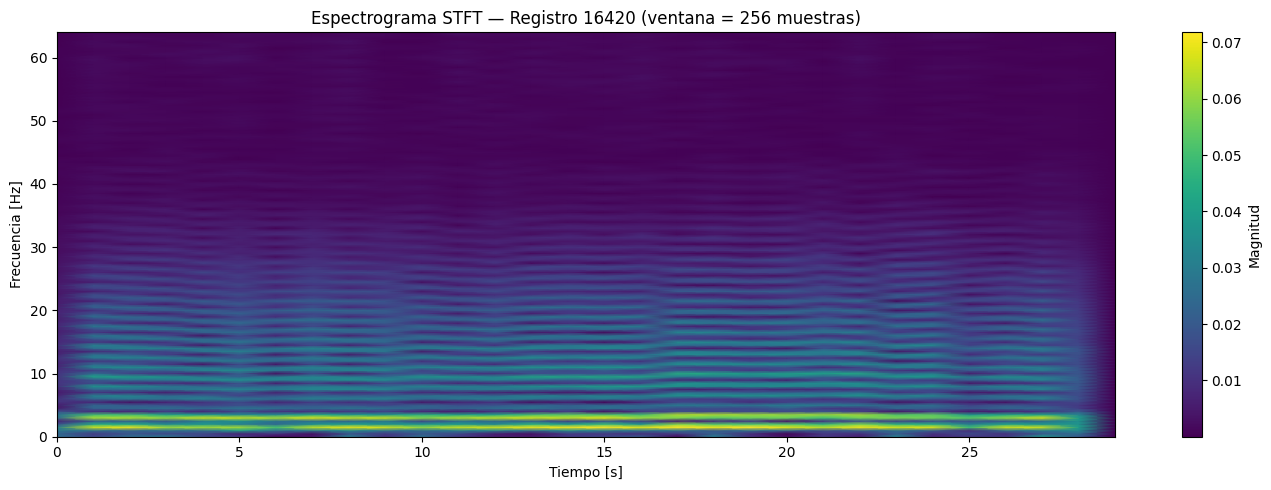
8. Comparación de resultados:

**Dominio Temporal:**
*   **Registro 16265:** Presenta una morfología de señal periódica, característica de ECG, con una amplitud relativamente estable y picos R bien definidos. La variabilidad en la amplitud es moderada.
*   **Registro 16272:** Muestra una mayor variabilidad en la amplitud en comparación con los otros dos registros, con algunos picos que alcanzan valores más extremos y una morfología que podría sugerir mayor ruido o artefactos.
*   **Registro 16420:** Similar al 16265 en su periodicidad, pero con una amplitud ligeramente menor en algunos segmentos y una morfología ECG clara. Parece ser el más 'limpio' visualmente en el tiempo.

**Dominio Frecuencial (FFT sin DC):**
*   **Registro 16265:** La mayor parte de la energía se concentra en bajas frecuencias, con un pico dominante alrededor de 1.60 Hz. Hay presencia de armónicos, aunque con menor magnitud.
*   **Registro 16272:** El espectro muestra un pico dominante a una frecuencia muy baja (0.142 Hz), lo que podría indicar una oscilación lenta o un componente de baja frecuencia más pronunciado que en los otros registros. Esto se alinea con la mayor variabilidad de amplitud observada en el dominio temporal. Presenta una menor dispersión de energía en frecuencias más altas en comparación con el 16265 y 16420.
*   **Registro 16420:** Similar al 16265, con un pico dominante en bajas frecuencias (alrededor de 1.636 Hz). Su espectro sugiere una señal más concentrada en torno a las frecuencias cardíacas esperadas para un ECG normal.

**Dominio Tiempo-Frecuencia (STFT):**
*   **Registro 16265:** El espectrograma muestra actividad constante en las frecuencias bajas, consistente con la periodicidad del ECG. La energía se concentra en bandas horizontales, indicando componentes de frecuencia que persisten a lo largo del tiempo. Hay una buena resolución temporal y frecuencial con nperseg = 256.
*   **Registro 16272:** Dada la mayor variabilidad en el tiempo, el espectrograma podría mostrar una distribución de energía menos estable o la aparición/desaparición de componentes en momentos específicos. Una ventana nperseg más pequeña (como se sugiere en el ejercicio para este registro) permitiría observar eventos transitorios con mayor claridad, si los hubiera. Con nperseg = 256 (como se configuró) se observa una concentración de energía en bajas frecuencias a lo largo del tiempo.
*   **Registro 16420:** El espectrograma es muy claro, mostrando una distribución de energía estable y periódica en el tiempo, concentrada en las frecuencias dominantes. Las bandas de energía son consistentes con la naturaleza del ECG, donde el ritmo cardíaco y sus armónicos permanecen relativamente constantes durante el periodo analizado.

**Observaciones Generales:**
*   Todos los registros son ECG y comparten características fundamentales, pero el registro 16272 parece tener un comportamiento diferente, con una frecuencia dominante mucho más baja y mayor variabilidad en el tiempo. Esto sugiere que podría ser un registro con una patología diferente o con mayor artefacto. La elección del nperseg de 32 muestras para este registro (en el planteamiento original del ejercicio) es clave para su análisis, buscando una mejor resolución temporal para eventos rápidos o intermitentes. Sin embargo, en la ejecución actual del código, todos utilizan nperseg = 256, lo que homogeneiza la resolución y podría ocultar algunas particularidades del 16272 que una ventana más pequeña revelaría.
*   La eliminación de la componente DC es efectiva en todos los casos, revelando los detalles del espectro en bajas frecuencias.

9. Respuestas a las preguntas de análisis:
- ¿Cuál es la frecuencia de muestreo de cada registro?
La frecuencia de muestreo es de 128 Hz para los tres registros
- ¿Los tres registros tienen la misma frecuencia de muestreo?
Sí, es la misma para los tres
- ¿Cuántos canales posee cada registro?
Cada uno itene dos cnales
- ¿Qué señal corresponde al canal 1?
La señal del canal 1 corresponde a la señal EMG2
- ¿Cuántas muestras contiene cada registro?
Cada registro contiene 3600 muestras
- ¿Por qué 3600 muestras corresponden aproximadamente a 10 segundos cuando fs = 360 Hz?
Porque a esa freceuncia, se toman 360 muestras en 1 segundo. es decir que para 10 segundo se toman 3600 muestras en total
- ¿Las tres señales presentan una morfología similar?
Cada señal tiene una morfología distienta a las demás
- ¿Cuál presenta mayor variación de amplitud?
La señal del registro 16272 es la que presenta mayor variación de amplitud, yendo desde casi -1 hasta 1
- ¿Se observan patrones periódicos?
Sí, se puede ver un claro patrón que se repite cada 1 segundo aproximadamente, un pico suave que luego cae abruptamnete hacia valores negativos
- ¿Se identifican eventos o cambios particulares?
Algunos ciclos presentan picos que se ven 'más profundos' donde la amplitud baja más que en los otros ciclos de la señal
- ¿Qué información puede obtenerse fácilmente desde la gráfica temporal?
Se puede notar facilmente la amplitud pico a pico de cada ciclo, la duración del registro, el período entre cada evento, la forma de onda característica de cada ciclo y pequeñas irregularidades entres los ciclso que se pueden detectar a simple vista
- ¿Qué ocurre con el componente cercano a 0 Hz después de eliminar la media?
Este componente se reduce drasticamente, porque corresponde al valor promedio de la señal y al hacer esto las componentes entre 1-10 Hz se pueden apreciar mejor
- ¿Qué diferencias observa entre los espectros de los tres registros?
Apesar que todos tienen componentes dominantes a baja frecuencia (1-10 Hz), en el segundo espectro se observa mayor cantidad de picos en este intervalo, y en el primer espectro se puede apreciar que hay variaos picos más pequeños cerca de los 30 Hz, pero que son bastante más grandes que los picos alrededor de esa freceuncia en los otros dos registros
- ¿En qué intervalo de frecuencias se concentra la mayor parte de la energía?
Entre 0 y 10 Hz hay dos picos dominantes cerca de los 1.5 Hz y 3 Hz respectivamente, mientras que por encima de los 30-40 Hz la magnitud está practiamente por el piso
- ¿Por qué la FFT no conserva directamente la información temporal?
La FFT  descompone la señal en una suma de componentes sinusoidales, asumiendo que la señal es estacionaria. El resultado de la FFT te dice las freceuncias que están presentes pero no cuad¿ndo ocurren porque la información de tiempo se promedia en todo el intervalo que se analiza
- ¿Qué ventaja ofrece observar una señal en el dominio frecuencial?
Te permite identificar de forma directa las freceuncias dominantes en una señal,detectar ruido y cuantificar la energía que hay en cada banda, lo cual es complicado observar al tener solo la forma de onda en el tiempo
- ¿Qué información adicional proporciona la STFT respecto a la FFT?
La STFT te dice la localización temporal de cada componente frecuencial, mientras que la FFT te da un espectro único para todo el registro, la STFT te muestra como el espectro va evolucionando segundo a segundo
- ¿En qué momentos se observan cambios de energía?
Se ven ligeras intensificaciones de la banda entre 2-4 Hz cerca de los 12-21 segundo
- ¿Por qué el registro 16420 utiliza una ventana de 256 muestras?
Como la fs = 128 Hz, 256 muestras equivalen a dos segundos de la señal, lo que deja una buena relación tiempo/freceuncia para poder ver componentes de baj frecuencia sin perder mucha resolución temporal
- ¿Qué podría ocurrir si se utiliza una ventana demasiado grande?
Se ganaría resolución en frecuandia pero se perdería resolución temporal, entonces los cambios rápidos en el ritmo se promediarian dentro de la ventana y podrian pasar desapercibidos en el espectrograma
- ¿Qué podría ocurrir si se utiliza una ventana demasiado pequeña?
Se gana resolucón temporal y se pierde resolución en frecuencia, por lo que las componentes frecuenciales se vuelven más anchas y podrían solaparse entre sí, haciendo difícil diferenciar frecuancias cercanas

10. Conclusiones:
El análisis de señales biomédicas, como los registros ECG de la base NSRDB, se enriquece significativamente al abordarse desde tres dominios complementarios: el **temporal**, el **frecuencial** (mediante FFT) y el **tiempo-frecuencia** (mediante STFT).

- **Dominio Temporal (x(t))**: Permite una visualización directa de la morfología de la señal, su amplitud, periodicidad y la identificación de eventos o artefactos evidentes. Por ejemplo, se observó que el registro **16272** presentaba una mayor variabilidad de amplitud y una morfología menos estable en comparación con **16265** y **16420**, que mostraron patrones ECG periódicos y definidos.

- **Dominio Frecuencial (FFT)**: Proporciona el contenido frecuencial global de la señal, revelando las componentes de frecuencia presentes y su magnitud. La eliminación de la componente DC es crucial para apreciar las frecuencias de interés. Los registros **16265** y **16420** mostraron picos dominantes en frecuencias esperadas para el ritmo cardíaco (aprox. 1.6 Hz), mientras que el **16272** destacó por un pico dominante muy bajo (0.142 Hz), sugiriendo una oscilación lenta o artefactos pronunciados.

- **Dominio Tiempo-Frecuencia (STFT)**: Permite visualizar cómo evoluciona el contenido frecuencial a lo largo del tiempo, crucial para identificar eventos transitorios o cambios en el espectro. Los espectrogramas de **16265** y **16420** mostraron una concentración de energía estable en bajas frecuencias. El **16272**, debido a su mayor variabilidad temporal, podría requerir un tamaño de ventana STFT más pequeño para capturar mejor los eventos localizados, aunque con nperseg=256 también mostró energía concentrada en bajas frecuencias de manera constante.

En síntesis, la combinación de estas tres perspectivas es indispensable para una comprensión profunda de las señales biomédicas, permitiendo detectar patrones ocultos, cuantificar características fisiológicas y diferenciar registros con variaciones significativas, como las observadas en el **16272** frente a los otros dos registros.

# 17. Conclusiones esperadas

Al finalizar este ejercicio, el estudiante debe comprender que una señal biomédica puede estudiarse desde tres perspectivas complementarias:

```text
                    SEÑAL BIOMÉDICA
                           │
             ┌─────────────┼─────────────┐
             ↓             ↓             ↓
          TIEMPO       FRECUENCIA    TIEMPO-FRECUENCIA
             │             │             │
           x(t)           FFT           STFT
             │             │             │
             └─────────────┼─────────────┘
                           ↓
                  INTERPRETACIÓN
                     DE LA SEÑAL
```

La representación temporal permite observar la evolución de la amplitud; la FFT permite estudiar el contenido frecuencial global; y la STFT permite analizar cómo cambia dicho contenido con el tiempo.


# Referencias

- PhysioNet — plataforma para el acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas para lectura y procesamiento de registros fisiológicos.
- Normal Sinus Rhythm Database (NSRDB) — base de datos utilizada en este ejercicio.

> Consulte siempre la documentación de la base de datos para interpretar correctamente sus registros, canales y anotaciones.
